In [1]:
import numpy as np
import matplotlib.pyplot as plt
from helpers import compute_N
from tqdm import tqdm
from helpers import *

In [ ]:
# Set the constants
T0 = 1.0                      # planar channel temperature
Uw = 0.1                      # wall velocity
Np = 50000                    # particles 
L = 1.0                       # distance between plates 
Tw = 1.0                      # wall temperature
m = 1.0                       # mass of argon 
k = 1.0                       # Boltzmann constant
tau = 0.05                    # relaxation time 
t = 0                         # initial time
t_end = 3.0                     # final time
dt = 0.001                    # timestep
Nsteps = int(t_end // dt) + 1 # number of steps
Nc = 10                       # number of cells
dx = L / Nc                   # space grid length
Tbar = 1.0                    # Correlated 

In [2]:
# Set the constants
T0 = 1.0                      # initial temperature
Tbar = 1.0                    # background temperature
Tw = 1.0                      # wall temperature
m = 1.0                       # mass
k = 1.0                       # Boltzmann constant

# Knudsen and Mach numbers
Kn = 0.1
Ma = 0.316

# Derived parameters
Uw = Ma * np.sqrt(k * Tw / m)          # = 0.316 wall velocity
tau = 2 * Kn / np.sqrt(np.pi / 2)     # ≈ 0.225 relaxation time

# Domain
L = 1.0
Nc = 10
dx = L / Nc                            # = 0.02

# Particles
Np = 50000                            # 5000 per cell

# Timestep from paper equation (100)
dt = 0.5 * L / (Nc * np.sqrt(k * Tw / m))  # = 0.01

# Simulation time
t_end = 50.0                            # 100 tau relaxation times
t = 0
Nsteps = int(t_end // dt) + 1

# NW bandwidth
h = 4 * dx                             # = 0.04

# Grid
x_grid = np.linspace(-L/2 + dx/2, L/2 - dx/2, Nc)

correlated_process = False

In [3]:
'''
def compute_cell_moments(M, cell_index, Nc, Mbar=None, Ubar=None):
    """
    Compute cell-averaged mean velocity and temperature for N_c cells.

    Parameters
    ----------
    M : ndarray, shape (Np, 3)
        Particle velocities.
    cell_index : ndarray, shape (Np,)
        Cell index for each particle.
    Nc : int
        Number of cells.
    m : float
        Particle mass.
    k : float
        Boltzmann constant.
    Mbar : ndarray, shape (Np, 3), optional
        Correlated/reference particle velocities (baseline).
        If provided, used for variance reduction: M_corrected = M - Mbar + Ubar[cell_index]
    Ubar : ndarray, shape (Nc, 3), optional
        Cell-averaged expected values of Mbar (for baseline correction).
        Required if Mbar is provided.

    Returns
    -------
    U : ndarray, shape (Nc, 3)
        Mean velocity in each cell.
    T : ndarray, shape (Nc,)
        Temperature in each cell.
    """    
    U = np.zeros((Nc, 3))
    T = np.zeros(Nc)

    if Mbar is not None:
        if Ubar is None:
            raise ValueError("If Mbar is provided, Ubar must also be provided")
        M_corrected = M - Mbar + Ubar[cell_index]
    else:
        M_corrected = M

    for c in range(Nc):
        mask = cell_index == c
        if mask.any():
            V_cell = M_corrected[mask]

            # Mean velocity
            U[c] = V_cell.mean(axis=0)

            # Temperature
            T[c] = (m / (3 * k)) * ((V_cell - U[c])**2).sum(axis=1).mean()
            
    return U, T
'''



def compute_cell_moments(M, cell_index, Nc, Mbar=None, Ubar=None):
    U = np.zeros((Nc, 3))
    T = np.zeros(Nc)
    
    if Mbar is not None:
        if Ubar is None:
            raise ValueError("If Mbar is provided, Ubar must also be provided")
        M_corrected = M - Mbar + Ubar[cell_index]  # Np x 3
    else:
        M_corrected = M

    for c in range(Nc):
        mask = cell_index == c
        if mask.any():
            V_cell = M_corrected[mask]
            U[c] = V_cell.mean(axis=0)
            
            residuals = V_cell - U[c]
            T[c] = (m / (3*k)) * (residuals**2).sum(axis=1).mean()
            
            if Mbar is not None:
                T[c] += Tbar
    
    return U, T

In [4]:
def evolve_velocity_M(M, mask, U_cell, T_cell, dt, tau, m, k, noise):
    M[mask] = (M[mask] - U_cell) * np.exp(-dt/tau) + U_cell + np.sqrt((k * T_cell / m) * (1 - np.exp(-2*dt/tau))) * noise

def evolve_velocity_Mbar(Mbar, N, mask, dt, tau, m, k, Tbar, noise, NiNi):
    """
    Evolve the correlated process Mbar using variance-reduced scheme.
    Mbar: Np x 3 array
    N: Np x 3 array, drift for each particle
    mask: boolean array for selected particles
    """
    #Ni_sq_mean = np.mean(N[mask]**2, axis=0)  
    #Ni_sq_mean = NiNi
    #print(f" max|Mbar| = {np.abs(Mbar).max():.4f}, max|M| = {np.abs(M).max():.4f}")
    #print(f"NiNi: {NiNi}, N[mask].mean(): {np.mean(N[mask]**2, axis=0)  }")
    #print(f"Old averaging diff to analytical: {(NiNi - N[mask]).mean():.4f} ± {(NiNi - N[mask]).std():.4f}")

    Mbar[mask] = np.exp(-dt/tau) * Mbar[mask] \
                 + dt * N[mask] \
                 + np.sqrt(np.maximum((k*Tbar/m) * (1 - np.exp(-2*dt/tau)) - dt**2 * NiNi, 0.0)) * noise

    Mbar[mask] = np.clip(Mbar[mask], -10*np.sqrt(k*Tbar/m), 10*np.sqrt(k*Tbar/m))

In [5]:
def apply_wall_bc(X, M, Mbar, L, Tw, Uw, m, k, Tbar):
    # Left wall
    left_mask = X < -L/2
    if left_mask.any():
        # Reflect particle back to boundary
        X[left_mask] = -L/2
        # Re-sample velocity
        N_left = left_mask.sum()
        r1_left = np.random.uniform(size=N_left)
        r2_left = np.random.uniform(size=N_left)
        r3_left = np.random.uniform(size=N_left)
        M[left_mask, 0] = np.sqrt(-2*k*Tw/m * np.log(r1_left))
        M[left_mask, 1] = np.sqrt(-2*k*Tw/m * np.log(r2_left)) * np.sin(2*np.pi*r3_left) + Uw
        M[left_mask, 2] = np.sqrt(-2*k*Tw/m * np.log(r2_left)) * np.cos(2*np.pi*r3_left)
        Mbar[left_mask, 0] = np.sqrt(-2*k*Tbar/m * np.log(r1_left))
        Mbar[left_mask, 1] = np.sqrt(-2*k*Tbar/m * np.log(r2_left)) * np.sin(2*np.pi*r3_left)
        Mbar[left_mask, 2] = np.sqrt(-2*k*Tbar/m * np.log(r2_left)) * np.cos(2*np.pi*r3_left)

    # Right wall
    right_mask = X > L/2
    if right_mask.any():
        X[right_mask] = L/2
        N_right = right_mask.sum()
        r1_right = np.random.uniform(size=N_right)
        r2_right = np.random.uniform(size=N_right)
        r3_right = np.random.uniform(size=N_right)
        M[right_mask, 0] = -np.sqrt(-2*k*Tw/m * np.log(r1_right))
        M[right_mask, 1] = np.sqrt(-2*k*Tw/m * np.log(r2_right)) * np.sin(2*np.pi*r3_right) - Uw
        M[right_mask, 2] = np.sqrt(-2*k*Tw/m * np.log(r2_right)) * np.cos(2*np.pi*r3_right)
        
        Mbar[right_mask, 0] = -np.sqrt(-2*k*Tbar/m * np.log(r1_right))
        Mbar[right_mask, 1] = np.sqrt(-2*k*Tbar/m * np.log(r2_right)) * np.sin(2*np.pi*r3_right)
        Mbar[right_mask, 2] = np.sqrt(-2*k*Tbar/m * np.log(r2_right)) * np.cos(2*np.pi*r3_right)

    return left_mask, right_mask

In [6]:
# Implementation of Algorithm 1 
X = np.random.uniform(low=-L/2, high=L/2, size=Np) 

r1 = np.random.uniform(size=Np) 
r2 = np.random.uniform(size=Np) 
r3 = np.random.uniform(size=Np) 
r4 = np.random.uniform(size=Np) 

M = np.zeros((Np, 3)) 
M[:, 0] = np.sqrt(-2 * k * T0 / m * np.log(r1)) * np.cos(2 * np.pi * r2) 
M[:, 1] = np.sqrt(-2 * k * T0 / m * np.log(r3)) * np.sin(2 * np.pi * r4) 
M[:, 2] = np.sqrt(-2 * k * T0 / m * np.log(r3)) * np.cos(2 * np.pi * r4) 

# Mbar: use same r's for correlation
Mbar = np.zeros((Np, 3)) 

Mbar[:, 0] = np.sqrt(-2 * k * Tbar / m * np.log(r1)) * np.cos(2*np.pi*r2)
Mbar[:, 1] = np.sqrt(-2 * k * Tbar / m * np.log(r3)) * np.sin(2*np.pi*r4)
Mbar[:, 2] = np.sqrt(-2 * k * Tbar / m * np.log(r3)) * np.cos(2*np.pi*r4)

U = np.zeros((Nsteps, Nc, 3)) 
T = np.zeros([Nsteps, Nc]) 

Ubar = np.zeros((Nc, 3))

cell_index = np.floor((X + L/2) / dx).astype(int) 
cell_index = np.clip(cell_index, 0, Nc-1) # make sure no particle is out of bounds 
U[0], T[0] = compute_cell_moments(M, cell_index, Nc, Mbar, Ubar)

for step in tqdm(range(1, Nsteps)):
    #print(f"Step {step}: max|Mbar| = {np.abs(Mbar).max():.4f}, max|M| = {np.abs(M).max():.4f}")

    # Evolve X^i 
    X = X + dt * M[:, 0] 
    
    # Apply B.C. 
    left_mask, right_mask = apply_wall_bc(X, M, Mbar, L, Tw, Uw, m, k, Tbar) 
    mask_wall = left_mask | right_mask # particles that just hit wall 

    # Sort particles 
    cell_index = np.floor((X + L/2) / dx).astype(int) 
    cell_index = np.clip(cell_index, 0, Nc-1) # make sure no particle is out of bounds
    if correlated_process:
        N, NiNi = compute_N(M, Mbar, U[step-1], Nc, X, L, dx, m, k, Tbar, tau) # NiNi

    if step in [1, 10, 50, 100, 200, 500, 750] and correlated_process:
        alpha = compute_alpha(M, Mbar, Nc, X, L, dx)
        cbar = compute_cbar(M, Mbar, U[step - 1], Nc, X, L, dx, m, k, Tbar, tau)
        
        print(f"\n{'='*50}")
        print(f"Step {step}")
        print(f"{'='*50}")
        
        print(f"\n  N statistics:")
        for d, name in enumerate(['x','y','z']):
            print(f"    N[{name}]: mean={np.mean(N[:,d]):+.4f}  std={np.std(N[:,d]):.4f}  max={np.abs(N[:,d]).max():.4f}")
        
        print(f"\n  Particle statistics:")
        print(f"    std(Mbar[:,0]) = {np.std(Mbar[:,0]):.4f}")
        print(f"    std(M-Mbar)    = {np.std(M[:,0]-Mbar[:,0]):.4f}")
        print(f"    mean(M-Mbar)   = {np.mean(M[:,0]-Mbar[:,0]):.4f}")
        
        print(f"\n  Coefficient statistics:")
        print(f"    alpha: mean={np.mean(alpha):+.4f}  std={np.std(alpha):.4f}  max={np.abs(alpha).max():.4f}")
        print(f"    cbar:  mean={np.mean(cbar):+.4f}  std={np.std(cbar):.4f}  max={np.abs(cbar).max():.4f}")
        print(f"    cbar diagonal only:")
        for d in range(3):
            print(f"      cbar[{d},{d}]: mean={np.mean(cbar[:,d,d]):+.4f}  std={np.std(cbar[:,d,d]):.4f}")
        
        # Energy correction health check
        NiNi = compute_NiNi_analytical(alpha, cbar, 
               compute_gammabar(alpha, M, Mbar, Nc, X, L, dx, m, k, Tbar, tau),
               -((m/(2*k*Tbar))**2)/tau, tau, Tbar)
        Atilde = (k*Tbar/m)*(1-np.exp(-2*dt/tau)) - dt**2 * NiNi
        print(f"\n  Energy correction A_tilde:")
        print(f"    min={Atilde.min():.6f}  mean={Atilde.mean():.6f}")
        pct_negative = 100 * np.mean(Atilde < 0)
        print(f"    % negative (clamped to 0): {pct_negative:.1f}%")
        print(f"{'='*50}\n")

        print(f"U[step,:,0] (wall-normal, should be ~0):")
        print(U[step-1,:,0])
        print(f"U[step,:,1] (streamwise, should be linear):")  
        print(U[step-1,:,1])
    

    for c in range(Nc): 
        mask_c = (cell_index==c) 
        mask_c_update = mask_c & (~mask_wall) # exclude wall-hitting particles, because they are already handled  
        if mask_c_update.any(): 
            # Evolve V^i
            noise = np.random.normal(0,1,size=M[mask_c_update].shape) # Common noise
            evolve_velocity_M(M, mask_c_update, U[step-1, c], T[step-1, c], dt, tau, m, k, noise)
            if correlated_process:
                evolve_velocity_Mbar(Mbar, N, mask_c_update, dt, tau, m, k, Tbar, noise, NiNi[c])  # NiNi

    if correlated_process:
        U[step], T[step] = compute_cell_moments(M, cell_index, Nc, Mbar, Ubar)
    else:
        U[step], T[step] = compute_cell_moments(M, cell_index, Nc)


100%|█████████████████████████████████████| 99999/99999 [25:08<00:00, 66.31it/s]


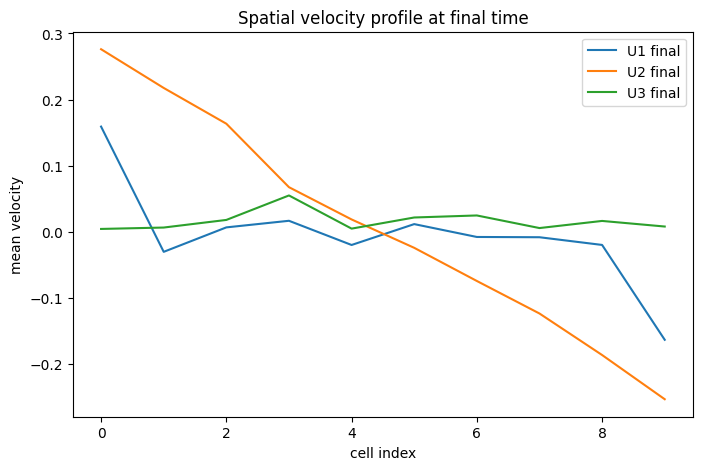

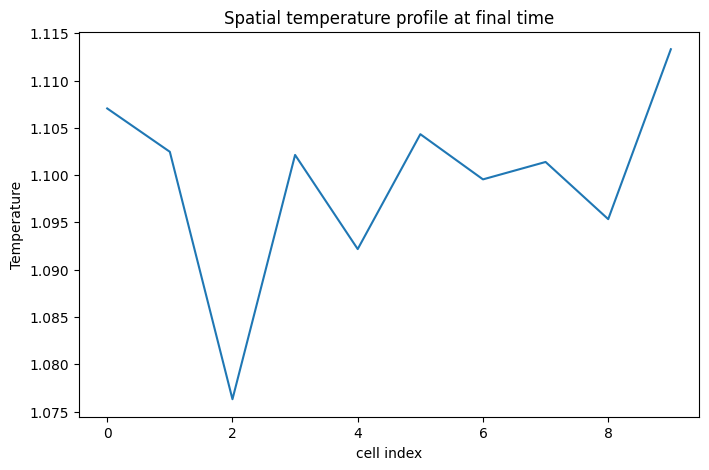

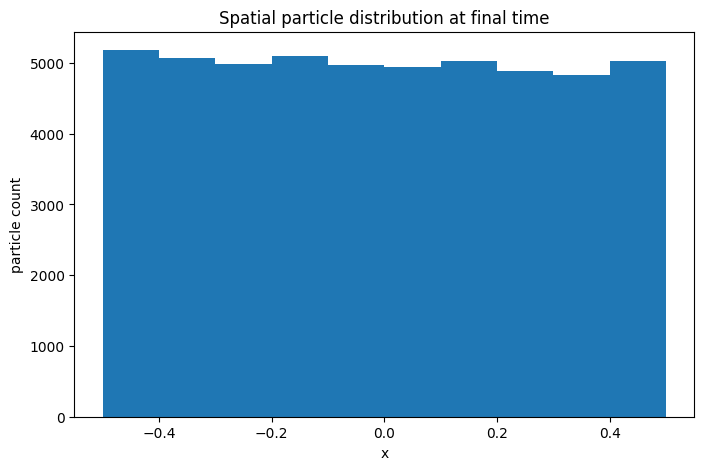

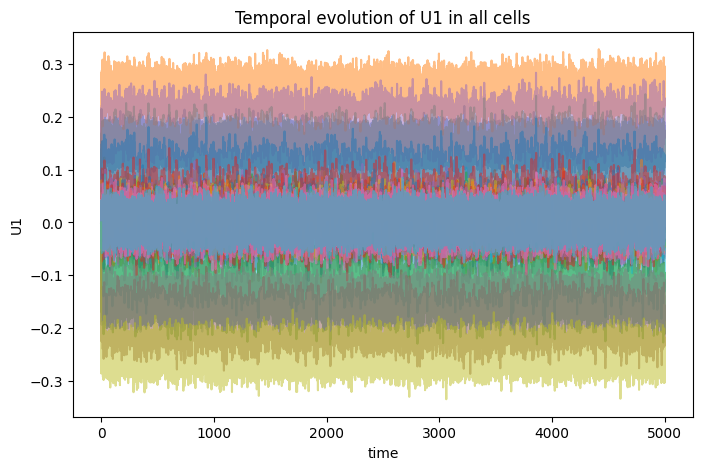

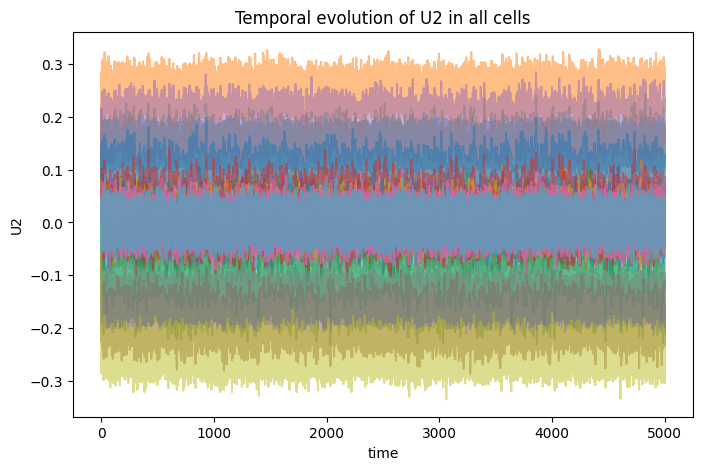

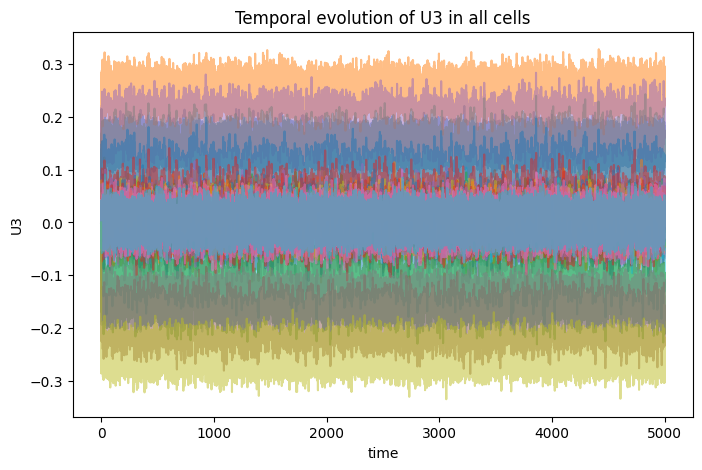

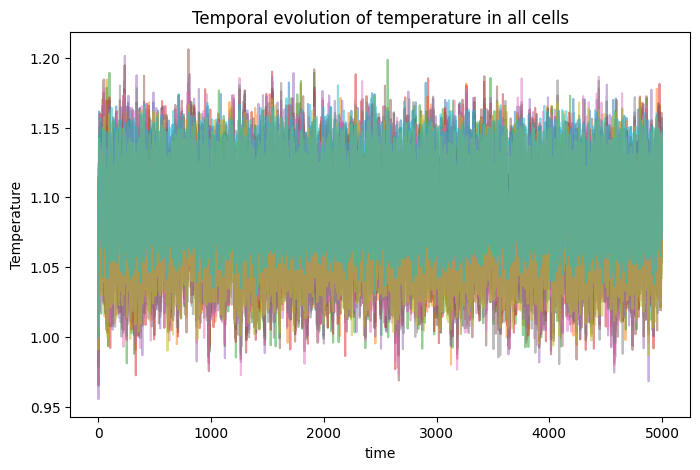

In [7]:
plt.figure(figsize=(8,5))
plt.plot(range(Nc), U[-1,:, 0], label='U1 final')
plt.plot(range(Nc), U[-1,:, 1], label='U2 final')
plt.plot(range(Nc), U[-1,:, 2], label='U3 final')
plt.legend()
plt.xlabel('cell index')
plt.ylabel('mean velocity')
plt.title('Spatial velocity profile at final time')
plt.show()

plt.figure(figsize=(8,5))
plt.plot(range(Nc), T[-1,:])
plt.xlabel('cell index')
plt.ylabel('Temperature')
plt.title('Spatial temperature profile at final time')
plt.show()

plt.figure(figsize=(8,5))
plt.hist(X, bins=Nc)
plt.xlabel('x')
plt.ylabel('particle count')
plt.title('Spatial particle distribution at final time')
plt.show()


plt.figure(figsize=(8,5))
for c in range(Nc):
    plt.plot(np.arange(Nsteps)*dt, U[:,c], alpha=0.5)
plt.xlabel('time')
plt.ylabel('U1')
plt.title('Temporal evolution of U1 in all cells')
plt.show()

plt.figure(figsize=(8,5))
for c in range(Nc):
    plt.plot(np.arange(Nsteps)*dt, U[:,c], alpha=0.5)
plt.xlabel('time')
plt.ylabel('U2')
plt.title('Temporal evolution of U2 in all cells')
plt.show()

plt.figure(figsize=(8,5))
for c in range(Nc):
    plt.plot(np.arange(Nsteps)*dt, U[:,c], alpha=0.5)
plt.xlabel('time')
plt.ylabel('U3')
plt.title('Temporal evolution of U3 in all cells')
plt.show()

plt.figure(figsize=(8,5))
for c in range(Nc):
    plt.plot(np.arange(Nsteps)*dt, T[:,c], alpha=0.5)
plt.xlabel('time')
plt.ylabel('Temperature')
plt.title('Temporal evolution of temperature in all cells')
plt.show()

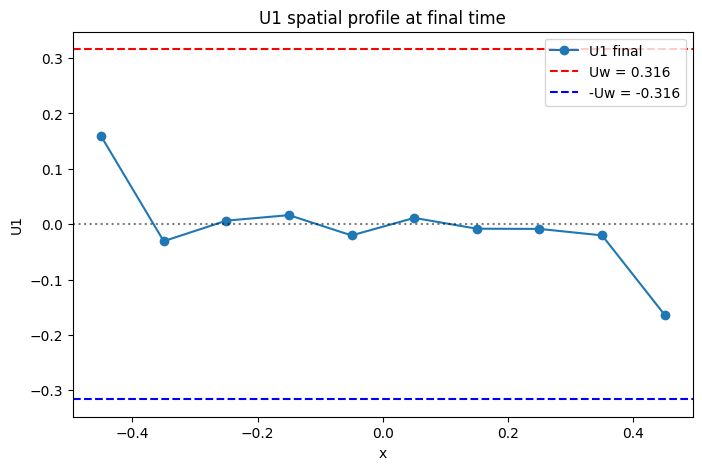

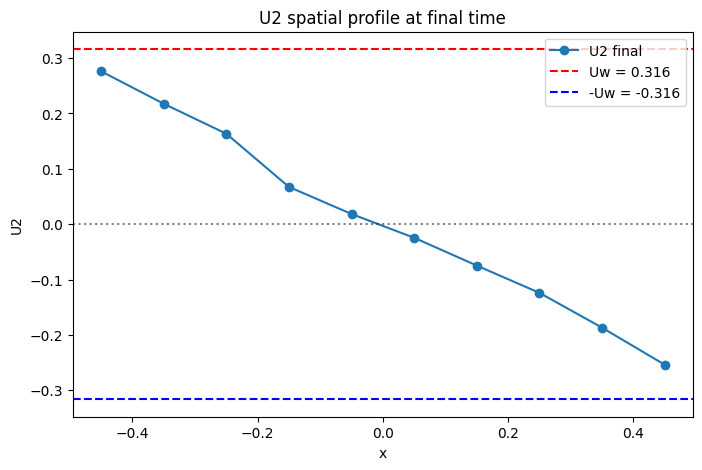

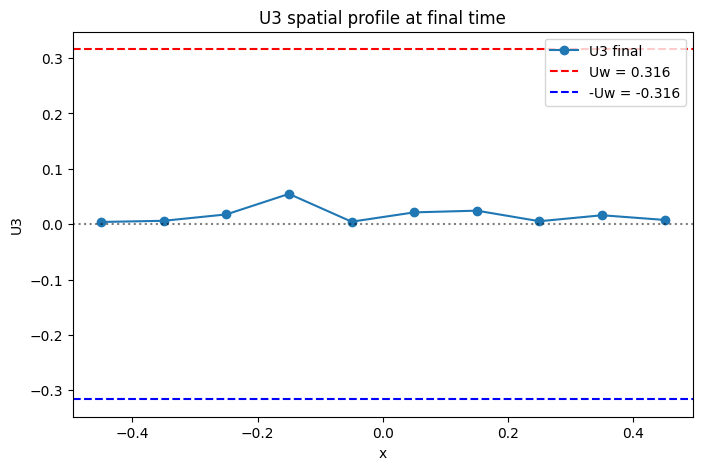

In [8]:
x_grid = np.linspace(-L/2 + dx/2, L/2 - dx/2, Nc)

plt.figure(figsize=(8,5))
plt.plot(x_grid, U[-1, :, 0], 'o-', label='U1 final')
plt.axhline(y=Uw, color='r', linestyle='--', label=f'Uw = {Uw}')
plt.axhline(y=-Uw, color='b', linestyle='--', label=f'-Uw = {-Uw}')
plt.axhline(y=0, color='k', linestyle=':', alpha=0.5)
plt.xlabel('x')
plt.ylabel('U1')
plt.title('U1 spatial profile at final time')
plt.legend()
plt.show()


plt.figure(figsize=(8,5))
plt.plot(x_grid, U[-1, :, 1], 'o-', label='U2 final')
plt.axhline(y=Uw, color='r', linestyle='--', label=f'Uw = {Uw}')
plt.axhline(y=-Uw, color='b', linestyle='--', label=f'-Uw = {-Uw}')
plt.axhline(y=0, color='k', linestyle=':', alpha=0.5)
plt.xlabel('x')
plt.ylabel('U2')
plt.title('U2 spatial profile at final time')
plt.legend()
plt.show()


plt.figure(figsize=(8,5))
plt.plot(x_grid, U[-1, :, 2], 'o-', label='U3 final')
plt.axhline(y=Uw, color='r', linestyle='--', label=f'Uw = {Uw}')
plt.axhline(y=-Uw, color='b', linestyle='--', label=f'-Uw = {-Uw}')
plt.axhline(y=0, color='k', linestyle=':', alpha=0.5)
plt.xlabel('x')
plt.ylabel('U3')
plt.title('U3 spatial profile at final time')
plt.legend()
plt.show()

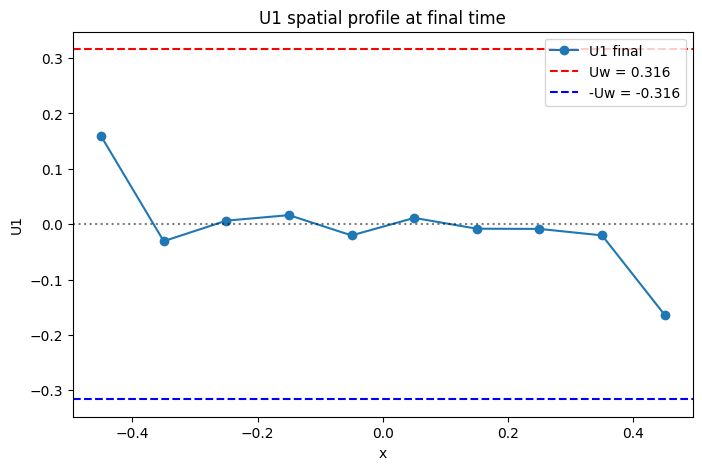

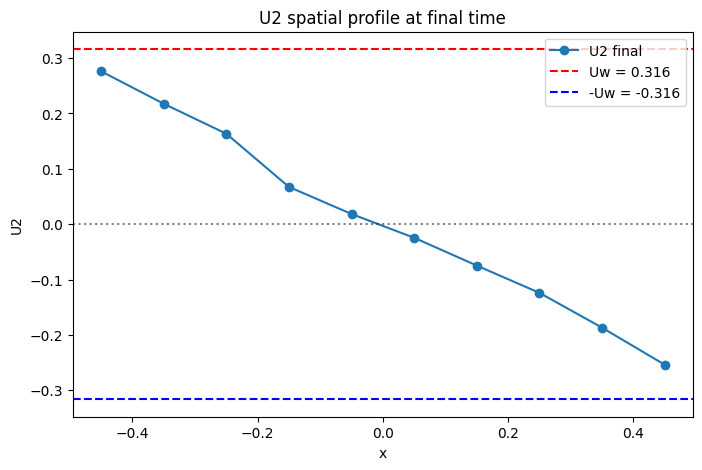

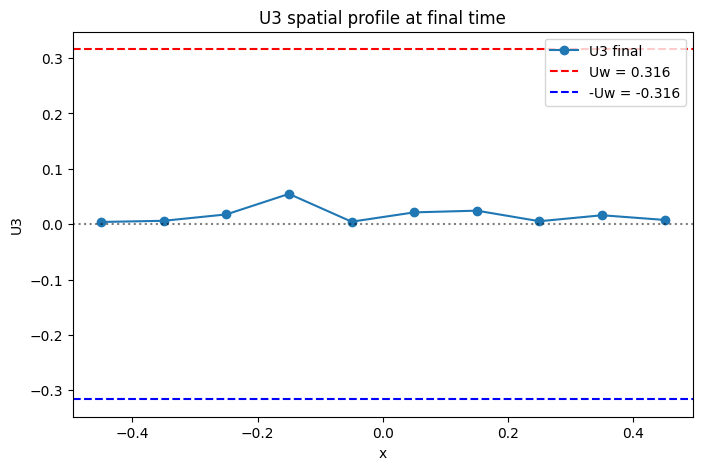

In [9]:
plt.figure(figsize=(8,5))
plt.plot(x_grid, U[-1, :, 0], 'o-', label='U1 final')
plt.axhline(y=Uw, color='r', linestyle='--', label=f'Uw = {Uw}')
plt.axhline(y=-Uw, color='b', linestyle='--', label=f'-Uw = {-Uw}')
plt.axhline(y=0, color='k', linestyle=':', alpha=0.5)
plt.xlabel('x')
plt.ylabel('U1')
plt.title('U1 spatial profile at final time')
plt.legend()
plt.show()


plt.figure(figsize=(8,5))
plt.plot(x_grid, U[-1, :, 1], 'o-', label='U2 final')
plt.axhline(y=Uw, color='r', linestyle='--', label=f'Uw = {Uw}')
plt.axhline(y=-Uw, color='b', linestyle='--', label=f'-Uw = {-Uw}')
plt.axhline(y=0, color='k', linestyle=':', alpha=0.5)
plt.xlabel('x')
plt.ylabel('U2')
plt.title('U2 spatial profile at final time')
plt.legend()
plt.show()


plt.figure(figsize=(8,5))
plt.plot(x_grid, U[-1, :, 2], 'o-', label='U3 final')
plt.axhline(y=Uw, color='r', linestyle='--', label=f'Uw = {Uw}')
plt.axhline(y=-Uw, color='b', linestyle='--', label=f'-Uw = {-Uw}')
plt.axhline(y=0, color='k', linestyle=':', alpha=0.5)
plt.xlabel('x')
plt.ylabel('U3')
plt.title('U3 spatial profile at final time')
plt.legend()
plt.show()